# 任务1.1

In [54]:
import pdfplumber
import pandas as pd
import os
import re

# 文件夹路径
folder_path = r"D:\desk\B题-特殊医学用途配方食品数据分析\数据\特医食品说明书"

# 要提取的营养成分及对应的列名
nutrient_mapping = {
    '能量': '能量(kJ)',
    '脂肪': '脂肪(g)',
    '碳水化合物': '碳水化合物(g)',
    '蛋白质': '蛋白质(g)',
    '钠': '钠(mg)',
    '氯': '氯(mg)',
    '钾': '钾(mg)',
    '磷': '磷(mg)',
    # 如果需要更多营养成分，可以在这里添加
}

# 初始化一个空的列表，用于存储所有的结果
results = []

# 获取文件夹中所有的PDF文件
pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

for pdf_file in pdf_files:
    file_path = os.path.join(folder_path, pdf_file)
    # 提取注册证号，假设文件名就是注册证号
    registration_number = os.path.splitext(pdf_file)[0]

    # 初始化一个空的列表，用于存储所有的DataFrame
    dfs = []
    # 保存最新的表头
    last_header = None

    # 打开 PDF 文件
    with pdfplumber.open(file_path) as pdf:
        table_found = False  # 标记是否找到表格
        # 遍历每一页
        for page_num, page in enumerate(pdf.pages):
            # 尝试提取所有表格
            tables = page.extract_tables()
            if tables:
                table_found = True
                for idx, table in enumerate(tables):
                    # 如果表格为空，跳过
                    if not table or len(table) == 0:
                        continue
                    # 检查表格的第一行是否是表头
                    first_row = table[0]
                    # 判断条件可以根据实际情况调整
                    if '营养成分' in first_row or '每100g' in first_row:
                        # 认为第一行是表头，保存表头
                        last_header = first_row
                        data_rows = table[1:]  # 数据行
                    else:
                        # 没有表头，使用之前保存的表头
                        if last_header is not None:
                            data_rows = table
                        else:
                            print(f"文件 {pdf_file} 第 {page_num+1} 页，第 {idx+1} 个表格缺少表头且没有之前的表头可用，跳过该表格。")
                            continue  # 跳过该表格
                
                    # 调整数据行，使其与表头的列数匹配
                    adjusted_data_rows = []
                    for row in data_rows:
                        # 如果行的长度与表头长度一致，直接添加
                        if len(row) == len(last_header):
                            adjusted_data_rows.append(row)
                        elif len(row) == 1:
                            # 尝试拆分单个字符串为多个列
                            split_row = re.split(r'\s+', row[0].strip())
                            if len(split_row) == len(last_header):
                                adjusted_data_rows.append(split_row)
                            else:
                                continue
                        else:
                            print(f"行的列数 {len(row)} 与表头列数 {len(last_header)} 不匹配，跳过该行：{row}")
                            continue
                
                    # 如果调整后的数据行为空，跳过该表格
                    if not adjusted_data_rows:
                        print(f"文件 {pdf_file} 第 {page_num+1} 页，第 {idx+1} 个表格的数据行无法匹配表头，跳过该表格。")
                        continue
                
                    # 现在创建 DataFrame
                    df = pd.DataFrame(adjusted_data_rows, columns=last_header)
                    # 将 DataFrame 添加到列表中
                    dfs.append(df)
            else:
                print(f"在文件 {pdf_file} 第 {page_num+1} 页未找到表格。")
        if not table_found:
            print(f"在文件 {pdf_file} 中未找到任何表格。")
            continue  # 跳过该PDF文件

    # 合并所有的DataFrame
    if dfs:
        try:
            combined_df = pd.concat(dfs, ignore_index=True)
        except Exception as e:
            print(f"在合并文件 {pdf_file} 的表格时发生错误: {e}")
            continue  # 跳过该PDF文件

        # 清理列名，去除可能的空格和特殊字符
        combined_df.columns = combined_df.columns.astype(str)
        combined_df.columns = combined_df.columns.str.strip().str.replace('\n', '').str.replace(' ', '')
        if '营养成分' not in combined_df.columns:
            print(f"在文件 {pdf_file} 的合并表格中未找到 '营养成分' 列，实际的列名是: {combined_df.columns.tolist()}")
            continue  # 跳过这个PDF文件

        try:
            # 清理数据行，去除可能的空格和特殊字符
            combined_df['营养成分'] = combined_df['营养成分'].astype(str).str.strip().str.replace('\n', '').str.replace(' ', '')
            # 去除'营养成分'中的括号及其中内容
            combined_df['营养成分_clean'] = combined_df['营养成分'].str.replace(r'（.*?）', '', regex=True)
            combined_df['营养成分_clean'] = combined_df['营养成分_clean'].str.replace(r'\(.*?\)', '', regex=True)
            combined_df['营养成分_clean'] = combined_df['营养成分_clean'].str.strip()

            # 初始化数据字典
            data = {'注册证号': registration_number}
            for nutrient_chinese, column_name in nutrient_mapping.items():
                # 找到对应的行，使用精确匹配
                matching_rows = combined_df[combined_df['营养成分_clean'] == nutrient_chinese]
                if not matching_rows.empty:
                    # 获取 '每100kJ' 列的值，并去除可能的空格
                    value = matching_rows['每100kJ'].values[0]
                    if isinstance(value, str):
                        value = value.strip()
                    data[column_name] = value
                else:
                    data[column_name] = None  # 如果没有找到，填充None
                    print(f"文件 {pdf_file} 未找到营养成分 {nutrient_chinese}")
            # 把结果添加到列表
            results.append(data)
        except Exception as e:
            print(f"在处理文件 {pdf_file} 时发生错误: {e}")
    else:
        print(f"在文件 {pdf_file} 中未找到任何表格。")

# 创建最终的 DataFrame
final_df = pd.DataFrame(results)

# 将列按照指定顺序排列
column_order = ['注册证号'] + list(nutrient_mapping.values())
final_df = final_df[column_order]

# 输出结果
print(final_df)


在文件 国食注字TY20175001.pdf 第 4 页未找到表格。
在文件 国食注字TY20175002.pdf 第 4 页未找到表格。
文件 国食注字TY20175003.pdf 第 1 页，第 1 个表格缺少表头且没有之前的表头可用，跳过该表格。
文件 国食注字TY20175003.pdf 第 2 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20175003.pdf 第 3 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
行的列数 5 与表头列数 4 不匹配，跳过该行：['建\n议\n喂\n哺\n表', '婴儿年龄', '每次喂哺量', None, '每24小时喂哺次数']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, None, '煮沸过的温开水（毫升）', '量匙数量', None]
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '0-2周', '60', '1', '8-10']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '2周-2月', '120', '2', '6-7']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '2月-6月', '180', '3', '5-6']
文件 国食注字TY20175003.pdf 第 3 页，第 3 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20175003.pdf 第 4 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
行的列数 5 与表头列数 4 不匹配，跳过该行：['', '6月-12月', '180', '3', '4-5']
文件 国食注字TY20175003.pdf 第 4 页，第 2 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 1 页，第 1 个表格缺少表头且没有之前的表头可用，跳过该表格。
文件 国食注字TY20180001.pdf 第 2 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 3 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 4 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180

In [56]:
final_df.to_excel('result1.xlsx',index=False)
final_df

,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
0,国食注字TY20175001,100,1.2,2.5,0.72,10.1,20.8,28.5,21.3
1,国食注字TY20175002,100,1.28,2.51,0.55,9,15,32,15
2,国食注字TY20175003,100.0,1.280,2.549,0.546,,15.38,31.47,10.49
3,国食注字TY20180001,100,1.3,2.6,0.56,8.4,15.4,24.7,13.1
4,国食注字TY20180002,100,0,5.8,0,271,416,184,14.6
...,...,...,...,...,...,...,...,...,...
176,国食注字TY20240018,100,0.76,3.15,0.95,23,18,32,11
177,国食注字TY20240019,100,0,0.3,5.6,11,None,None,None
178,国食注字TY20240020,100,2.3,0.69,0.22,3.2,None,None,None
179,国食注字TY20240021,100,0,5.71,0.18,14.17,None,None,None


In [59]:
final_df = pd.read_excel('result1.xlsx')
# 将蛋白质列转换为数值类型，处理可能的非数值字符
final_df['蛋白质(g)'] = pd.to_numeric(final_df['蛋白质(g)'], errors='coerce')

# 按蛋白质含量降序排序，并提取前三个数据
top_protein_df = final_df.sort_values(by='蛋白质(g)', ascending=False).head(3)

top_protein_df


,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
133,国食注字TY20230045,100.0,0.04,0.007,5.9,45.0,0.0,0.0,0.0
150,国食注字TY20230062,100.0,0.00,0.080,5.8,24.0,0.0,0.0,0.0
78,国食注字TY20220002,100.0,0.00,0.100,5.8,80.4,0.0,0.0,0.0


# 任务1.2

In [66]:
import os
import pandas as pd
import pdfplumber

# PDF 文件夹路径
pdf_folder = r"D:\desk\B题-特殊医学用途配方食品数据分析\数据\特医食品说明书"

# 读取 data.xlsx 数据
data_file = r"D:\desk\B题-特殊医学用途配方食品数据分析\数据\data.xlsx"  # 请将此路径替换为实际 data.xlsx 的路径
data_df = pd.read_excel(data_file)

# 在 DataFrame 中新增三列
data_df['产品类别'] = None
data_df['组织状态'] = None
data_df['适用人群'] = None

# 用于存储无法提取的 PDF 文件路径
failed_pdfs = []

# 遍历 DataFrame 的每一行
for index, row in data_df.iterrows():
    registration_number = row['注册证号']  # 假设注册证号的列名为 '注册证号'
    # 根据注册证号找到对应的 PDF 文件
    pdf_file_name = registration_number + '.pdf'
    pdf_path = os.path.join(pdf_folder, pdf_file_name)
    
    # 检查 PDF 文件是否存在
    if not os.path.exists(pdf_path):
        print(f"PDF 文件不存在: {pdf_path}")
        failed_pdfs.append(pdf_path)
        continue  # 跳过这个文件
    
    try:
        with pdfplumber.open(pdf_path) as pdf:
            # 初始化提取的字段
            product_category = None  # 产品类别
            physical_state = None    # 组织状态
            suitable_population = None  # 适用人群
            # 标记是否成功提取所有字段
            success = True
            # 遍历 PDF 的每一页
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    lines = text.split('\n')
                    for line in lines:
                        line = line.strip()
                        # 提取 '产品类别'
                        if ('产品类别' in line or '产品类别：' in line or '产品类别:' in line) and not product_category:
                            parts = line.split('产品类别')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                product_category = content
                        # 提取 '组织状态'
                        if ('组织状态' in line or '组织状态：' in line or '组织状态:' in line) and not physical_state:
                            parts = line.split('组织状态')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                physical_state = content
                        # 提取 '适用人群'
                        if ('适用人群' in line or '适用人群：' in line or '适用人群:' in line) and not suitable_population:
                            parts = line.split('适用人群')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                suitable_population = content
                # 如果已经提取到所有字段，可以停止遍历
                if product_category and physical_state and suitable_population:
                    break
            # 检查是否成功提取所有字段
            if not product_category or not physical_state or not suitable_population:
                print(f"未能从文件 {pdf_path} 提取所有字段")
                failed_pdfs.append(pdf_path)
                success = False
            # 如果成功，更新 DataFrame
            if success:
                data_df.at[index, '产品类别'] = product_category
                data_df.at[index, '组织状态'] = physical_state
                data_df.at[index, '适用人群'] = suitable_population
    except Exception as e:
        print(f"处理文件 {pdf_path} 时发生错误: {e}")
        failed_pdfs.append(pdf_path)

# 保存结果到 result2.xlsx
output_file = r"result2.xlsx"  # 请将此路径替换为您希望保存结果的路径
data_df.to_excel(output_file, index=False)

# 输出无法提取的 PDF 文件路径
if failed_pdfs:
    print("以下 PDF 文件未能提取到所有字段：")
    for pdf in failed_pdfs:
        print(pdf)
else:
    print("所有 PDF 文件均成功提取。")


所有 PDF 文件均成功提取。


In [67]:
# 去除“产品类别”、“组织状态”、“适用人群”列中的无效符号
data_df['产品类别'] = data_df['产品类别'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df['组织状态'] = data_df['组织状态'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df['适用人群'] = data_df['适用人群'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df.to_excel(r'result2.xlsx',index=False)
data_df.head()

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿


# 任务1.3

In [68]:
import pandas as pd

# 读取 result2.xlsx 文件
file_path = "result2.xlsx"
data_df = pd.read_excel(file_path)

# 新增“适用人群类别”列，初始值为 None
data_df['适用人群类别'] = None

# 根据“适用人群”信息进行归类
def categorize_population(row):
    suitable_population = str(row['适用人群'])
    if '婴儿' in suitable_population or '0-12月龄' in suitable_population:
        return '特医婴配食品'
    else:
        return '1岁以上特医食品'

# 应用归类规则
data_df['适用人群类别'] = data_df.apply(categorize_population, axis=1)

# 保存结果到 result2.xlsx
output_file = r"D:\desk\泰迪杯B代码\result2.xlsx"
data_df.to_excel(output_file, index=False)

print("已完成分类并保存到文件 result2.xlsx。")


已完成分类并保存到文件 result2.xlsx。


In [69]:
data_df

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿,特医婴配食品
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿,特医婴配食品
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿,特医婴配食品
...,...,...,...,...,...,...,...,...
177,费森尤斯卡比华瑞制药有限公司,德瑞清®特殊医学用途流质配方食品,国食注字TY20240017,2028-12-13,非全营养配方食品,液态,10岁以上需要限制脂肪摄入、消化吸收障碍等医学状况下的人群。,1岁以上特医食品
178,江苏冬泽特医食品有限公司,冬泽益全特殊医学用途全营养配方食品,国食注字TY20240018,2029-04-01,全营养配方食品,液态,10岁以上进食受限、消化吸收障碍、代谢紊乱等需要补充营养的人群。,1岁以上特医食品
179,江苏冬泽特医食品有限公司,冬泽力亮特殊医学用途蛋白质组件配方食品,国食注字TY20240019,2029-04-01,非全营养配方食品,液态,10岁以上特定疾病或医学状况下需要补充蛋白质的人群。,1岁以上特医食品
180,江苏冬泽特医食品有限公司,冬泽益能特殊医学用途脂肪组件配方食品,国食注字TY20240020,2029-04-01,脂肪（脂肪酸）组件,粉状,1岁以上特定疾病或者医学状况下需要补充中链脂肪的人群。,1岁以上特医食品


# 任务1.4

In [71]:
# 读取 result2_updated.xlsx 文件
data_df = pd.read_excel(output_file)

# 新增“产品来源”和“登记年份”两列，初始值为 None
data_df['产品来源'] = None
data_df['登记年份'] = None

# 根据注册号提取“产品来源”和“登记年份”
def extract_source_and_year(row):
    registration_number = str(row['注册证号'])
    # 提取年号和顺序号
    year = registration_number[6:10]
    sequence_first_digit = registration_number[10]
    
    # 判断产品来源
    if sequence_first_digit == '5':
        source = '进口产品'
    elif sequence_first_digit == '0':
        source = '国产产品'
    else:
        source = None  # 若不符合则设为 None
    
    return source, year

# 应用提取规则
data_df[['产品来源', '登记年份']] = data_df.apply(
    lambda row: pd.Series(extract_source_and_year(row)), axis=1
)

data_df


,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿,特医婴配食品,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿,特医婴配食品,国产产品,2018
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿,特医婴配食品,进口产品,2018
...,...,...,...,...,...,...,...,...,...,...
177,费森尤斯卡比华瑞制药有限公司,德瑞清®特殊医学用途流质配方食品,国食注字TY20240017,2028-12-13,非全营养配方食品,液态,10岁以上需要限制脂肪摄入、消化吸收障碍等医学状况下的人群。,1岁以上特医食品,国产产品,2024
178,江苏冬泽特医食品有限公司,冬泽益全特殊医学用途全营养配方食品,国食注字TY20240018,2029-04-01,全营养配方食品,液态,10岁以上进食受限、消化吸收障碍、代谢紊乱等需要补充营养的人群。,1岁以上特医食品,国产产品,2024
179,江苏冬泽特医食品有限公司,冬泽力亮特殊医学用途蛋白质组件配方食品,国食注字TY20240019,2029-04-01,非全营养配方食品,液态,10岁以上特定疾病或医学状况下需要补充蛋白质的人群。,1岁以上特医食品,国产产品,2024
180,江苏冬泽特医食品有限公司,冬泽益能特殊医学用途脂肪组件配方食品,国食注字TY20240020,2029-04-01,脂肪（脂肪酸）组件,粉状,1岁以上特定疾病或者医学状况下需要补充中链脂肪的人群。,1岁以上特医食品,国产产品,2024


In [72]:

data_df.to_excel(output_file, index=False)
output_file

'D:\\desk\\泰迪杯B代码\\result2.xlsx'

# 任务2.1

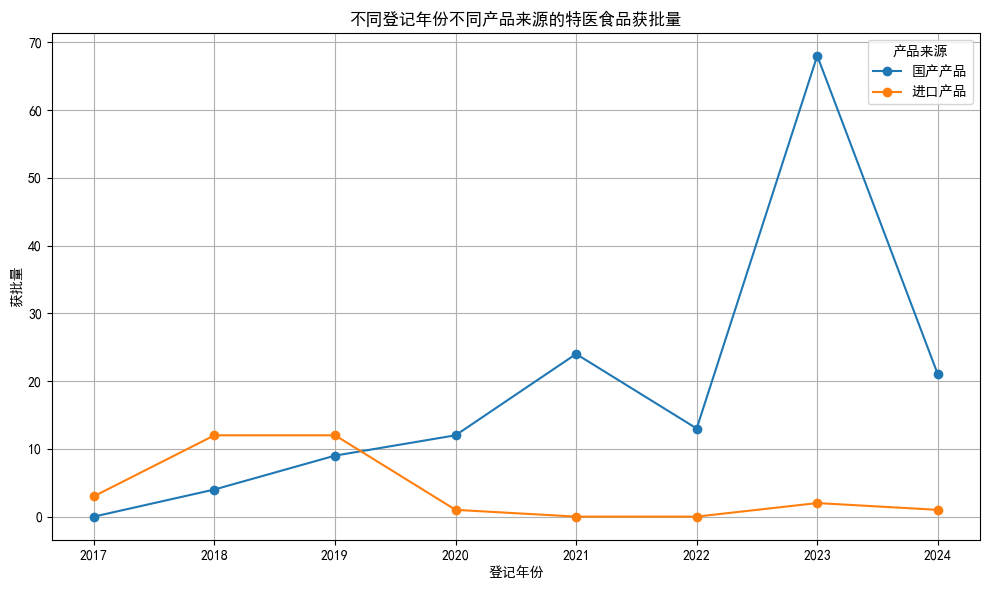

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] 
plt.rcParams['axes.unicode_minus']=False 

# 读取最新的 result2.xlsx 文件
file_path = output_file
data_df = pd.read_excel(file_path)

# 按“登记年份”和“产品来源”分组统计特医食品获批量
approval_stats = data_df.groupby(['登记年份', '产品来源']).size().unstack(fill_value=0)

# 绘制双折线图
plt.figure(figsize=(10, 6))
for source in approval_stats.columns:
    plt.plot(approval_stats.index, approval_stats[source], marker='o', label=source)

plt.title('不同登记年份不同产品来源的特医食品获批量')
plt.xlabel('登记年份')
plt.ylabel('获批量')
plt.legend(title='产品来源')
plt.grid(True)
plt.tight_layout()

# 显示图表
plt.show()


# 任务2.2

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


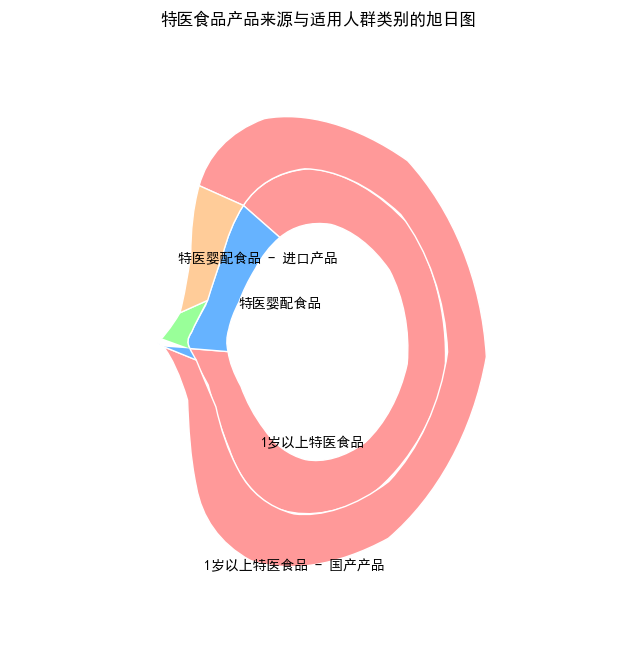

In [75]:
import matplotlib.pyplot as plt

# 根据特医食品的“产品来源”和“适用人群类别”统计数据
sunburst_data = data_df.groupby(['适用人群类别', '产品来源']).size().unstack(fill_value=0)

# 设置颜色
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

# 绘制旭日图
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 内层饼图表示适用人群类别
inner_values = sunburst_data.sum(axis=1)
inner_labels = inner_values.index
ax.pie(inner_values, radius=1, labels=inner_labels, colors=colors[:len(inner_values)], 
       wedgeprops=dict(width=0.3, edgecolor='w'), labeldistance=0.7)

# 外层饼图表示适用人群类别的产品来源分布
outer_values = sunburst_data.values.flatten()
outer_labels = [f"{outer_category} - {source}" for outer_category in sunburst_data.index 
                for source in sunburst_data.columns]
ax.pie(outer_values, radius=1.3, labels=outer_labels, colors=colors[:len(outer_values)],
       wedgeprops=dict(width=0.3, edgecolor='w'), labeldistance=1.1)

# 设置标题
plt.title("特医食品产品来源与适用人群类别的旭日图", va='bottom')
plt.show()


# 任务 2.3

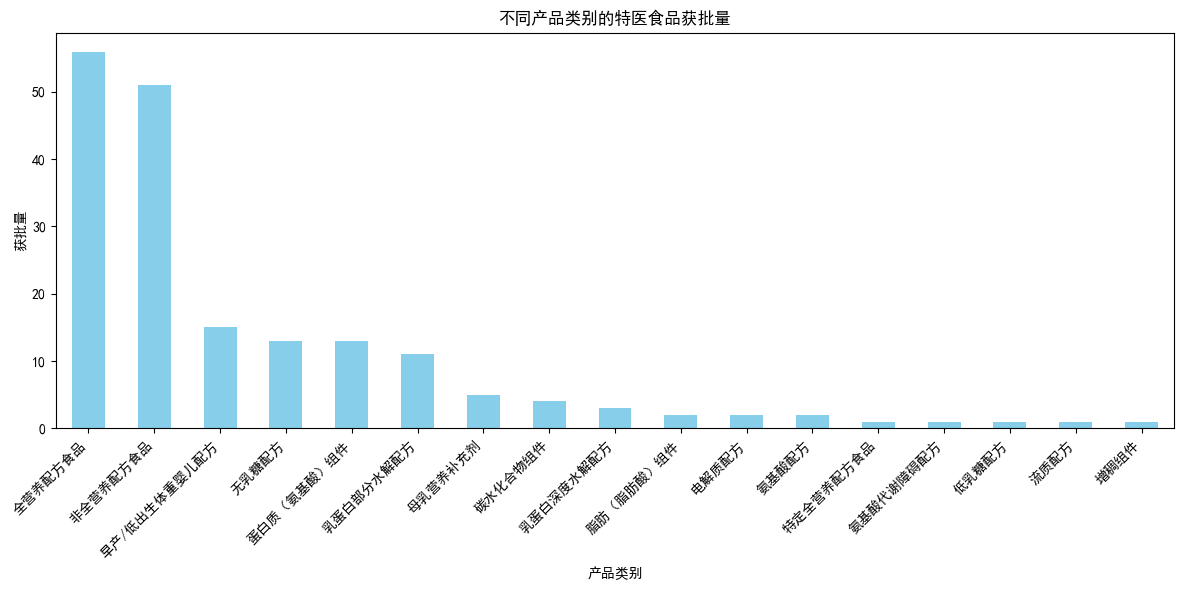

In [76]:
product_category_stats = data_df['产品类别'].value_counts().sort_values(ascending=False)

# 绘制柱状图
plt.figure(figsize=(12, 6))
product_category_stats.plot(kind='bar', color='skyblue')
plt.title("不同产品类别的特医食品获批量")
plt.xlabel("产品类别")
plt.ylabel("获批量")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# 任务2.4

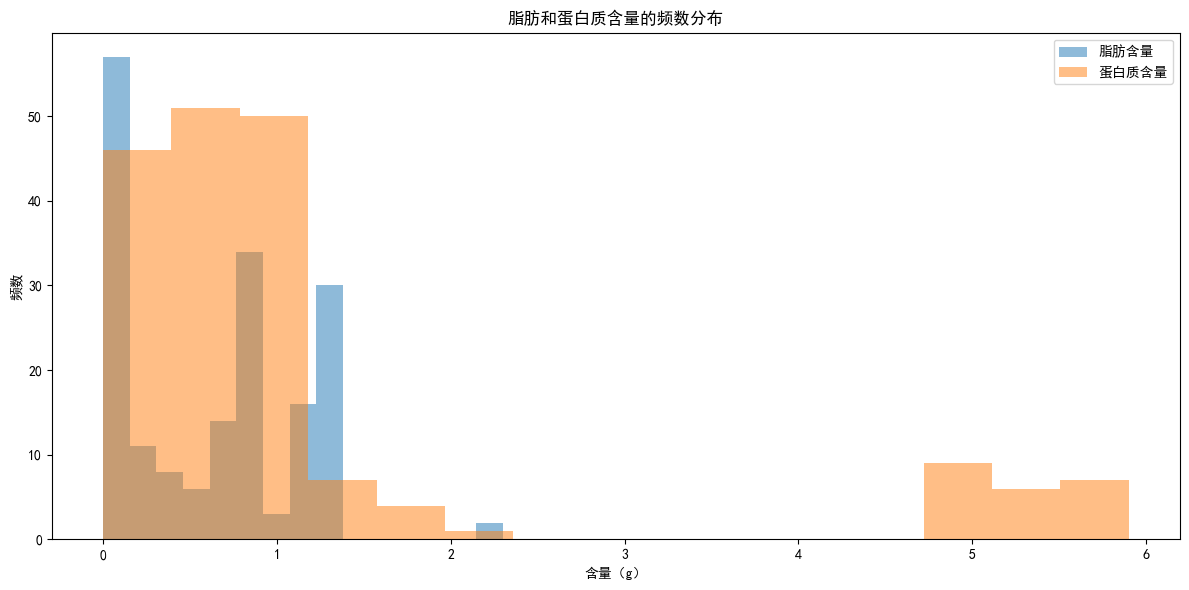

In [83]:

new_file_path = "result1.xlsx"
new_data_df = pd.read_excel(new_file_path)
# 绘制脂肪和蛋白质含量的频数分布直方图
plt.figure(figsize=(12, 6))
plt.hist(new_data_df['脂肪(g)'].dropna(), bins=15, alpha=0.5, label='脂肪含量')
plt.hist(new_data_df['蛋白质(g)'].dropna(), bins=15, alpha=0.5, label='蛋白质含量')
plt.title("脂肪和蛋白质含量的频数分布")
plt.xlabel("含量（g）")
plt.ylabel("频数")
plt.legend()
plt.tight_layout()
plt.show()


# 任务2.5

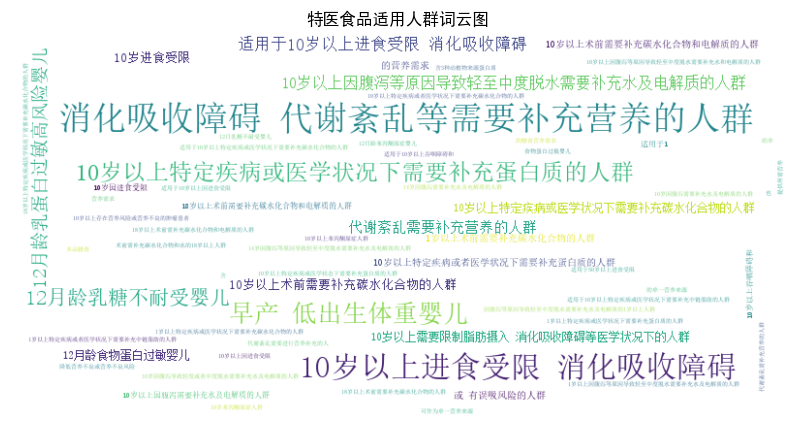

In [81]:
from wordcloud import WordCloud

# 将适用人群列拼接成一个字符串
suitable_population_text = " ".join(data_df['适用人群'].dropna().astype(str).tolist())

# 生成词云图，指定中文字体
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis', 
    font_path=r'C:\Windows\Fonts\simsun.ttc',  # 更改中文本机字体
    max_words=100
).generate(suitable_population_text)

# 显示词云图
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("特医食品适用人群词云图")
plt.show()


# 任务3.1

In [84]:
import pandas as pd

data_df = pd.read_excel(file_path)

# 定义推荐函数
def recommend_products(age_group=None, symptom=None, special_note=None):
    """
    根据客户的需求条件推荐特医食品。
    
    参数:
    - age_group (str): 年龄段，如 "婴儿" 或 "1岁以上"
    - symptom (str): 特定症状，如 "过敏" 或 "肠胃"
    - special_note (dict): 特殊说明，例如 {"产品来源": "进口产品", "组织状态": "粉状"}
    
    返回:
    - DataFrame: 符合条件的产品选项
    """
    # 初始化筛选条件
    filtered_df = data_df
    
    # 根据年龄段筛选
    if age_group:
        if age_group == "婴儿":
            filtered_df = filtered_df[filtered_df['适用人群类别'] == '特医婴配食品']
        elif age_group == "1岁以上":
            filtered_df = filtered_df[filtered_df['适用人群类别'] == '1岁以上特医食品']
    
    # 根据症状筛选
    if symptom:
        filtered_df = filtered_df[filtered_df['适用人群'].str.contains(symptom, na=False)]
    
    # 根据特殊说明筛选
    if special_note:
        for key, value in special_note.items():
            if key in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[key] == value]
    
    # 如果没有找到符合条件的产品，返回提示信息
    if filtered_df.empty:
        print("未找到符合条件的特医食品。")
        return pd.DataFrame()  # 返回空的 DataFrame
    
    # 返回符合条件的产品选项
    return filtered_df[['企业名称', '产品名称', '注册证号', '产品类别', '组织状态', '适用人群', '产品来源', '登记年份']]

# 示例用法
# 客户需求示例：0-12月龄婴儿，食物过敏，要求进口产品
recommended_products = recommend_products(
    age_group="婴儿",
    symptom="过敏",
    special_note={"产品来源": "进口产品"}
)

# 显示推荐的产品
recommended_products


,企业名称,产品名称,注册证号,产品类别,组织状态,适用人群,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,氨基酸配方,粉状,食物蛋白过敏婴儿,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,进口产品,2017
5,MEAD JOHNSON B.V.,亲舒特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20185002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2018
17,NESTLE NEDERLAND B.V.,蔼儿舒特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20185012,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2018
20,Nestlé Deutschland AG,超启能恩特殊医学用途婴儿乳蛋白部分水解配方食品,国食注字TY20195002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2019
36,Nestle Nederland B.V.,肽敏舒ALTHÉRA®特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20195010,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2019
46,Nestle Nederland B.V.,恩敏舒特殊医学用途婴儿氨基酸配方食品,国食注字TY20205001,氨基酸配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2020
96,Nutricia Cuijk B.V.,纽太特特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20235001,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2023
135,雀巢德国有限公司,启赋®敏适特殊医学用途婴儿乳蛋白部分水解配方食品,国食注字TY20235002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2023
